# The kappa ensemble adjoints: stability, the gradient with respect to vertical diffusivity, and how the pathways depend on κ_v

Eight 5-yr approximate adjoints (runs 31206, 31208–31220) of the production configuration, one per member of the vertical-diffusivity ladder (0.25× to 32× the reference 1.2e-5 m² s⁻¹), each from its own leg's year-180 pickup (`forward_legs.ipynb`). Same cost as always: the terminal-30-day mean Atlantic heat transport across 26° N.

Three questions. (1) Is the approximate adjoint stable over five years for every member? (2) Does the adjoint gradient with respect to a *uniform* κ_v, the sum of `adxx_diffkr` over the wet cells, agree with finite differences — both the factor-of-two secants between members and a dedicated ±10 % pair from the reference pickup (runs 31231/31232, forward sweeps only)? (3) How does the sensitivity structure change with κ_v, lead by lead?

In [1]:
import os, glob, json, warnings
import numpy as np, xmitgcm
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
warnings.filterwarnings('ignore')
SCRATCH = '/scratch2/tshahriar/DINO_1deg_outputs'; A = SCRATCH + '/runs/adjoint'
AN = SCRATCH + '/analysis/kappa_v_ensemble_ReMax2_approxAdv'; FIG_DIR = AN + '/figures'; os.makedirs(FIG_DIR, exist_ok=True)
KAPPA = {'M1': 3.0e-6, 'M2': 6.0e-6, 'REF': 1.2e-5, 'M3': 2.4e-5, 'M4': 4.8e-5, 'M5': 9.6e-5, 'M6': 1.92e-4, 'M7': 3.84e-4}
JOBS = {'REF': 31206, 'M1': 31208, 'M2': 31210, 'M3': 31212, 'M4': 31214, 'M5': 31216, 'M6': 31218, 'M7': 31220}
ORDER = ['M1', 'M2', 'REF', 'M3', 'M4', 'M5', 'M6', 'M7']
def find(job):
    hits = glob.glob(f'{A}/*run{job}') + glob.glob(f'{A}/*/*run{job}'); assert hits, job; return hits[0]
RUNS = {m: find(j) for m, j in JOBS.items()}
SPD = 48
def par(d, name): return int([l for l in open(d + '/data') if name in l and not l.strip().startswith('#')][0].split('=')[1].strip(' ,\n'))
def dumps(d, var):
    fs = sorted(glob.glob(f'{d}/{var}.*.data')); its = np.array([int(os.path.basename(f).split('.')[1]) for f in fs])
    return fs, (par(d, 'nIter0') + par(d, 'nTimeSteps') - its) / SPD
def rd(f, dt='>f4'): return np.fromfile(f, dtype=dt).astype('f8')
J = {m: float([l.split('=')[-1] for l in open(RUNS[m] + '/STDOUT.0000') if 'global fc' in l][0]) for m in ORDER}
g = xmitgcm.open_mdsdataset(RUNS['REF'], grid_dir=RUNS['REF'], prefix=[], iters=None, read_grid=True, geometry='curvilinear')
XC, YC, Z, hF = g.XC.values, g.YC.values, g.Z.values, g.hFacC.values; wet = hF > 0

member  kappa     J       finite  rms(30d)  rms(1yr)  rms(2yr)  rms(3yr)  rms(5yr)  onset of growth


M1     3.00e-06 0.3944  True   4.49e-04  9.44e+02  1.65e+06  1.23e+04  5.43e+03  185 d


M2     6.00e-06 0.3909  True   4.20e-04  3.65e-04  9.59e-02  2.32e-01  5.75e-03  370 d


REF    1.20e-05 0.3350  True   3.96e-04  9.34e-05  6.76e-05  7.11e-05  4.81e-05  none


M3     2.40e-05 0.2476  True   3.83e-04  7.59e-05  6.10e-05  6.03e-05  3.50e-05  none


M4     4.80e-05 0.2594  True   3.73e-04  6.92e-05  4.95e-05  4.06e-05  2.88e-05  none


M5     9.60e-05 0.2902  True   3.45e-04  6.36e-05  4.37e-05  3.55e-05  2.73e-05  none


M6     1.92e-04 0.3469  True   2.90e-04  5.94e-05  4.19e-05  3.50e-05  2.59e-05  none


M7     3.84e-04 0.4889  True   2.48e-04  5.69e-05  4.07e-05  3.45e-05  2.36e-05  none


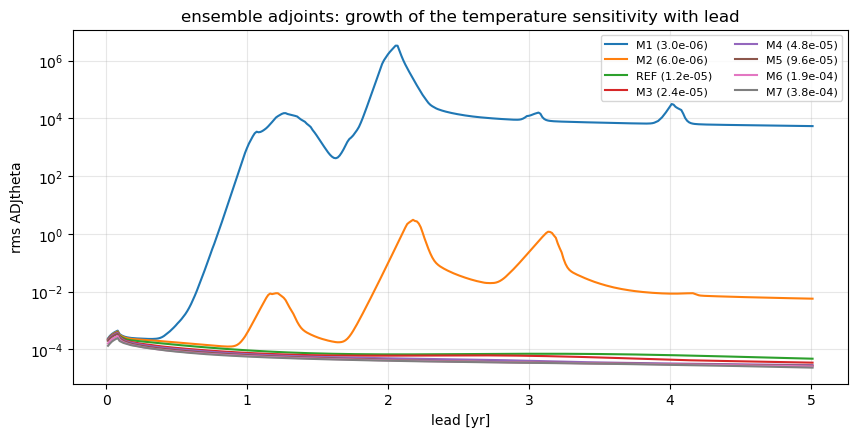

In [2]:
# (1) stability
stab = {}
print('member  kappa     J       finite  rms(30d)  rms(1yr)  rms(2yr)  rms(3yr)  rms(5yr)  onset of growth')
for m in ORDER:
    fs, lead = dumps(RUNS[m], 'ADJtheta'); rms = np.array([np.sqrt(np.mean(rd(f)**2)) for f in fs]); fin = all(np.isfinite(rd(f)).all() for f in fs)
    o = np.argsort(lead); lead, rms = lead[o], rms[o]; runmin = np.minimum.accumulate(rms); k = np.where(rms > 3 * runmin)[0]; onset = lead[k[0]] if len(k) else None
    stab[m] = (lead, rms, onset)
    at = lambda L: rms[np.argmin(np.abs(lead - L))]
    print(f"{m:6s} {KAPPA[m]:.2e} {J[m]:.4f}  {str(fin):6s} {at(30):.2e}  {at(365):.2e}  {at(730):.2e}  {at(1095):.2e}  {at(1825):.2e}  {f'{onset:.0f} d' if onset else 'none'}")
fig, ax = plt.subplots(figsize=(10, 4.6))
for m in ORDER: ax.semilogy(stab[m][0] / 365.25, stab[m][1], lw=1.5, label=f'{m} ({KAPPA[m]:.1e})')
ax.set_xlabel('lead [yr]'); ax.set_ylabel('rms ADJtheta'); ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8, ncol=2); ax.set_title('ensemble adjoints: growth of the temperature sensitivity with lead')
fig.savefig(f'{FIG_DIR}/ensemble_adjoint_growth.png', dpi=110, bbox_inches='tight')

small-amplitude check at REF (+-10 % kappa, runs 31231/31232): J 0.335016 -> 0.331758 / 0.338329; dJ/dkappa finite difference -2.7381e+03, adjoint -3.3096e+03, 1 - fd/adj = +0.173

member  adjoint dJ/dln(kappa) = G*kappa   central secant between the neighbouring members   ratio
M1     -4200972.8228         +nan      +nan
M2          +3.5202      -0.0428    -82.18
REF         -0.0397      -0.1034     +0.38
M3          -0.0064      -0.0545     +0.12
M4          +0.0365      +0.0307     +1.19
M5          +0.0705      +0.0631     +1.12
M6          +0.1343      +0.1433     +0.94
M7          +0.2574         +nan      +nan


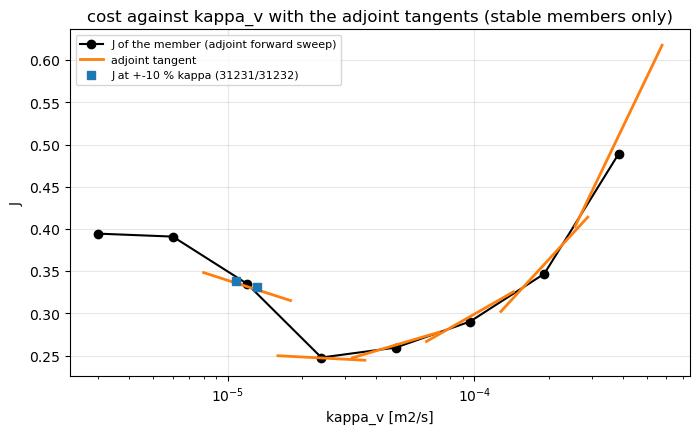

In [3]:
# (2) the gradient with respect to a uniform kappa
G = {m: float(np.sum(rd(f'{RUNS[m]}/adxx_diffkr.0000000000.data', '>f8').reshape(36, 198, 51)[wet])) for m in ORDER}
fd = json.load(open(AN + '/fd_check_uniform_kappa.json'))
print(f"small-amplitude check at REF (+-10 % kappa, runs 31231/31232): J {fd['J_ref']:.6f} -> {fd['J_p10']:.6f} / {fd['J_m10']:.6f}; dJ/dkappa finite difference {fd['fd_central']:+.4e}, adjoint {fd['adjoint_G']:+.4e}, 1 - fd/adj = {1 - fd['fd_central']/fd['adjoint_G']:+.3f}")
print('\nmember  adjoint dJ/dln(kappa) = G*kappa   central secant between the neighbouring members   ratio')
for i, m in enumerate(ORDER):
    lo, hi = (ORDER[i-1] if i else None), (ORDER[i+1] if i + 1 < len(ORDER) else None)
    sec = (J[hi] - J[lo]) / np.log(KAPPA[hi] / KAPPA[lo]) if lo and hi else np.nan
    print(f"{m:6s} {G[m]*KAPPA[m]:+12.4f}   {sec:+10.4f}   {G[m]*KAPPA[m]/sec if lo and hi else np.nan:+7.2f}")
fig, ax = plt.subplots(figsize=(8, 4.5)); k = np.array([KAPPA[m] for m in ORDER]); ax.set_xscale('log')
ax.plot(k, [J[m] for m in ORDER], 'ko-', label='J of the member (adjoint forward sweep)')
for m in ['REF', 'M3', 'M4', 'M5', 'M6', 'M7']:
    kk = np.array([KAPPA[m] / 1.5, KAPPA[m] * 1.5]); ax.plot(kk, J[m] + G[m] * (kk - KAPPA[m]), 'C1-', lw=2, label='adjoint tangent' if m == 'REF' else None)
ax.plot([1.08e-5, 1.32e-5], [fd['J_m10'], fd['J_p10']], 'C0s', ms=6, label='J at +-10 % kappa (31231/31232)')
ax.set_xlabel('kappa_v [m2/s]'); ax.set_ylabel('J'); ax.grid(alpha=0.3); ax.legend(fontsize=8); ax.set_title('cost against kappa_v with the adjoint tangents (stable members only)')
fig.savefig(f'{FIG_DIR}/cost_vs_kappa_with_adjoint_tangents.png', dpi=110, bbox_inches='tight')

spatial correlation of ADJtheta with REF by lead [d]      adxx_diffkr corr
member      30     180     365     730    1095    1460    1825
M1       0.972   0.181   0.000   0.000   0.015   0.009   0.053     0.008


M2       0.991   0.792   0.260   0.001  -0.001  -0.023  -0.047    -0.003


M3       0.993   0.788   0.835   0.742   0.564   0.624   0.734     0.600
M4       0.983   0.626   0.715   0.645   0.501   0.539   0.640     0.261


M5       0.971   0.560   0.638   0.622   0.458   0.436   0.515     0.141
M6       0.949   0.500   0.529   0.463   0.347   0.341   0.402     0.080


M7       0.896   0.456   0.427   0.317   0.261   0.255   0.300     0.051


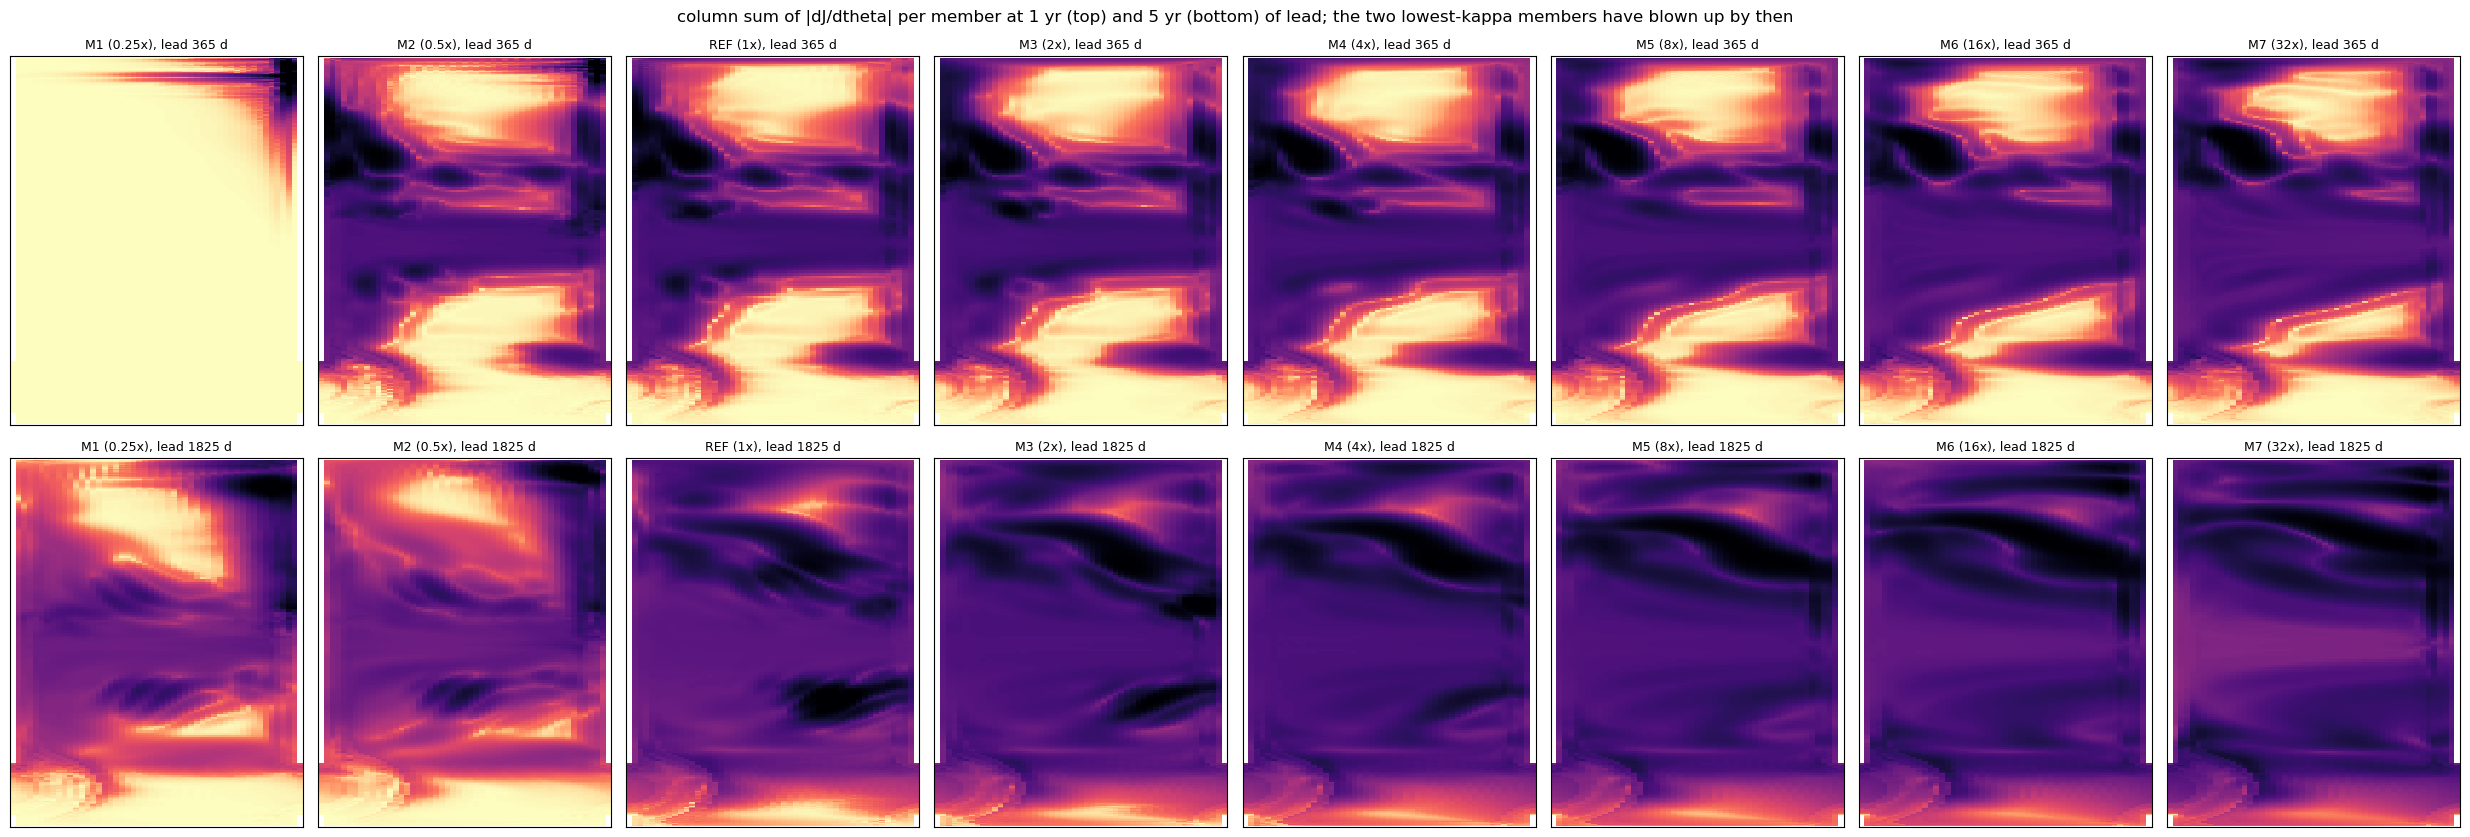

In [4]:
# (3) sensitivity structure vs kappa: correlation with REF by lead, and the maps at 1 yr and 5 yr
fsR, leadR = dumps(RUNS['REF'], 'ADJtheta'); hdr = [30, 180, 365, 730, 1095, 1460, 1825]
print('spatial correlation of ADJtheta with REF by lead [d]      adxx_diffkr corr'); print('member ' + ' '.join(f'{L:>7d}' for L in hdr))
gR = rd(f"{RUNS['REF']}/adxx_diffkr.0000000000.data", '>f8')
for m in ORDER:
    if m == 'REF': continue
    fs, lead = dumps(RUNS[m], 'ADJtheta'); row = []
    for L in hdr:
        a, b = rd(fs[np.argmin(np.abs(lead - L))]), rd(fsR[np.argmin(np.abs(leadR - L))]); mm = (a != 0) | (b != 0); row.append(np.corrcoef(a[mm], b[mm])[0, 1])
    gm = rd(f'{RUNS[m]}/adxx_diffkr.0000000000.data', '>f8'); mm = (gm != 0) | (gR != 0)
    print(f'{m:6s} ' + ' '.join(f'{x:7.3f}' for x in row) + f'   {np.corrcoef(gm[mm], gR[mm])[0, 1]:7.3f}')
fig, ax = plt.subplots(2, len(ORDER), figsize=(3.1 * len(ORDER), 8.5), squeeze=False)
for r, L in enumerate((365, 1825)):
    for cc, m in enumerate(ORDER):
        fs, lead = dumps(RUNS[m], 'ADJtheta'); Af = rd(fs[np.argmin(np.abs(lead - L))]).reshape(36, 198, 51)
        col = np.nansum(np.abs(Af) * wet, axis=0); vmax = np.nanpercentile(col[col > 0], 99.5)
        im = ax[r, cc].pcolormesh(XC, YC, np.where(col > 0, col, np.nan), norm=SymLogNorm(linthresh=vmax * 1e-3, vmin=0, vmax=vmax), cmap='magma_r', shading='auto')
        ax[r, cc].set_title(f'{m} ({KAPPA[m]/1.2e-5:g}x), lead {L} d', fontsize=9); ax[r, cc].set_xticks([]); ax[r, cc].set_yticks([])
fig.suptitle('column sum of |dJ/dtheta| per member at 1 yr (top) and 5 yr (bottom) of lead; the two lowest-kappa members have blown up by then'); fig.tight_layout()
fig.savefig(f'{FIG_DIR}/ensemble_sensitivity_maps_1yr_5yr.png', dpi=100, bbox_inches='tight')

## Reading

- **Stability.** Six of the eight adjoints — the reference and every member with κ_v at or above 2× — are finite and decay smoothly over the whole five years, the more strongly the larger κ_v (rms at 5 yr 4.8e-5 for the reference, 2.4e-5 at 32×). The two lowest-diffusivity members grow, with an 18-day e-folding time in episodic bursts, from 6 months (0.25×) and 12 months (0.5×) of lead, seeded at 1.8 km depth at 60 to 65° N on the eastern side of the northern basin. The flux limiter is not in the adjoint sweep, so this is a tangent-linear instability of the weakly stratified low-diffusivity state, a different mechanism from the one this configuration removed, and it would need a regularised adjoint (viscosity or diffusivity inflation in the adjoint sweep) if those members are wanted.
- **The gradient with respect to κ_v.** At the reference, the ±10 % finite difference gives dJ/dκ = −2.74e3 (forward and backward differences within 1.6 %, so the response is linear at that amplitude) against −3.31e3 from the adjoint: the right sign, the magnitude 21 percent high. On the diffusive branch (4× to 16×) the adjoint's dJ/dlnκ matches the central secants between neighbouring members within 6 to 19 percent; around the minimum of J(κ) (reference, 2×) the factor-of-two secants are dominated by the curvature and are not a test of anything. The blown members' gradients are meaningless.
- **Pathways depend on κ_v.** The sensitivity pattern correlates with the reference's at 0.90 to 0.99 in the first month for every member, then diverges with κ_v distance: at one year 0.84 for 2× down to 0.43 for 32×, at five years 0.73 and 0.30; the integrated diffusivity sensitivity (`adxx_diffkr`) correlates 0.60 at 2× and 0.05 at 32×. Beyond the first months the sensitivity pathways are a property of the mean state's vertical mixing, which is what the surrogate question of the 2026-08 campaign asked.